# Single line-of-sight diagnostics

Walk one ray and verify the ray tracing: the per-segment profile (`plot_los_profile`) and the r/θ/φ voxel staircase proof (`plot_los_voxel_proof`). The verdict PASS means every kept coordinate lies inside its assigned cell and the geometry residuals are ~0.

In [6]:
import numpy as np
from rrt import synthdata
from rrt.observer import make_observer
from rrt.los import analyze_los

In [7]:
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
from rrt.io import load_mhd
from rrt.observer import make_observer, make_observer_from_time
from rrt.response import load_response
from rrt.los import sample_along_los, plot_los_profile, plot_los_voxel_proof, analyze_los

REPO = Path.cwd().resolve()
while not (REPO / 'data' / 'rho_bin.h5').exists() and REPO != REPO.parent:
    REPO = REPO.parent

OBS_TIME, WAVELENGTH = '2024-03-30T20:49:00', 171

cube = load_mhd(str(REPO / 'data' / 'rho_bin.h5'),
                temperature=str(REPO / 'data' / 't_bin.h5'),
                fmt='mas', ne_scale=1.0e8, t_scale=2.807e7, r_range=(1.03, 5.0))
print(cube.summary())

T_resp, R_resp = load_response(str(REPO / 'data' / 'aia_temp_response_chiantifix.npz'), WAVELENGTH)
n_obs, e_los, x_img, y_img = make_observer_from_time(OBS_TIME)   # or make_observer(-70, 0)


MHDCube  case=separate  fmt=mas
  r     : 1.031 – 4.932 R_sun  (n=161)
  theta : -1.4 – 181.0 deg  (n=140)
  phi   : -1.1 – 361.1 deg  (n=224)
  ne    : 3.09e+03 – 4.74e+10 cm^-3   shape=(161, 140, 224)
  T     : 4.51e+04 – 3.42e+06 K   [K]


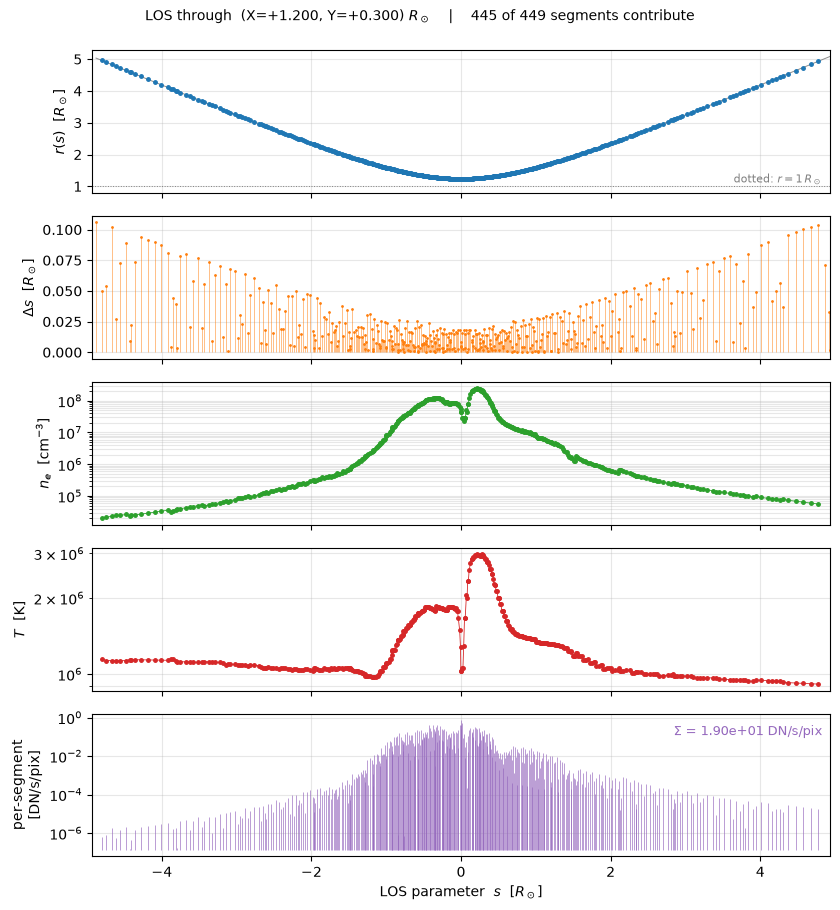

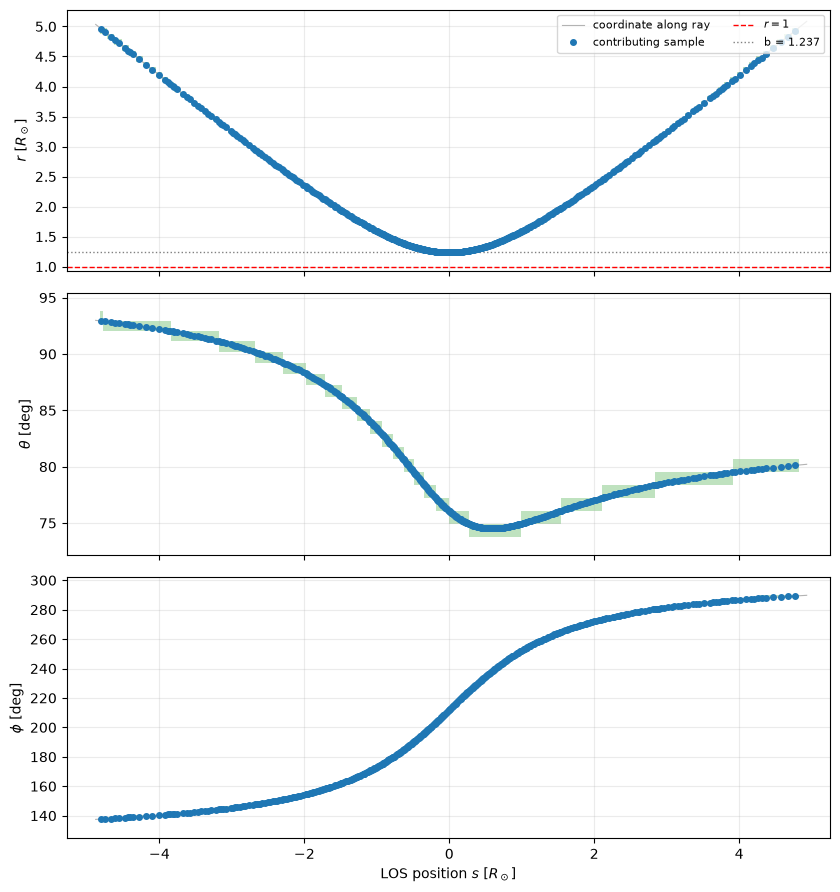

(+1.20,+0.30)  kept=445/449  Σ=1.899e+01 DN/s/pix  inside=100.0%  verdict=PASS


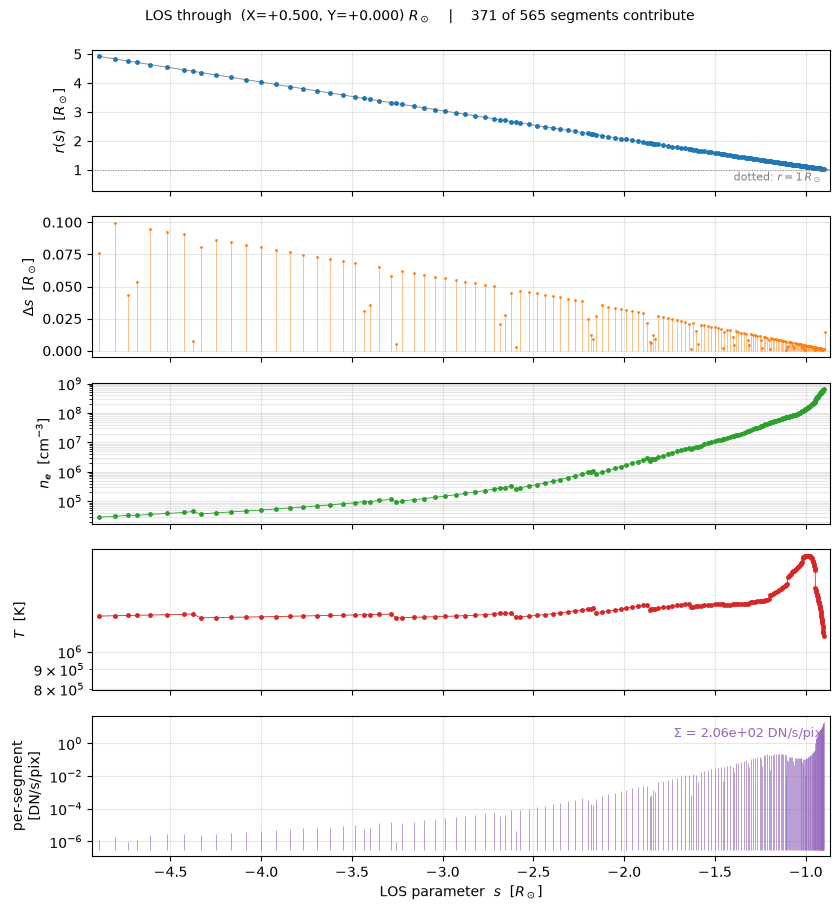

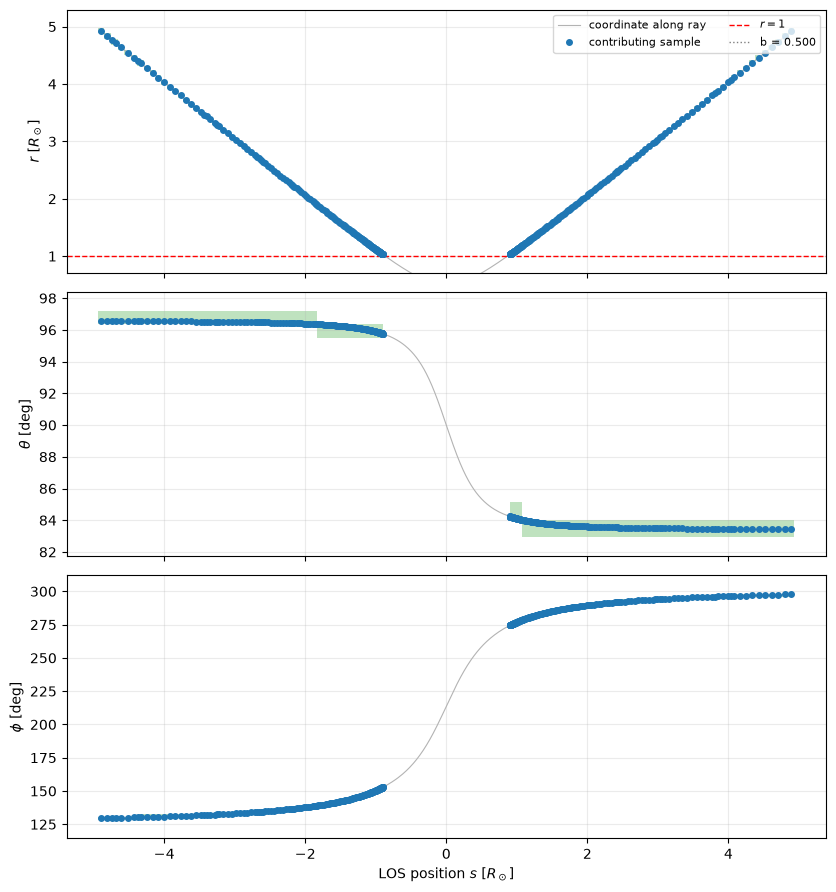

(+0.50,+0.00)  kept=371/565  Σ=2.062e+02 DN/s/pix  inside=100.0%  verdict=PASS


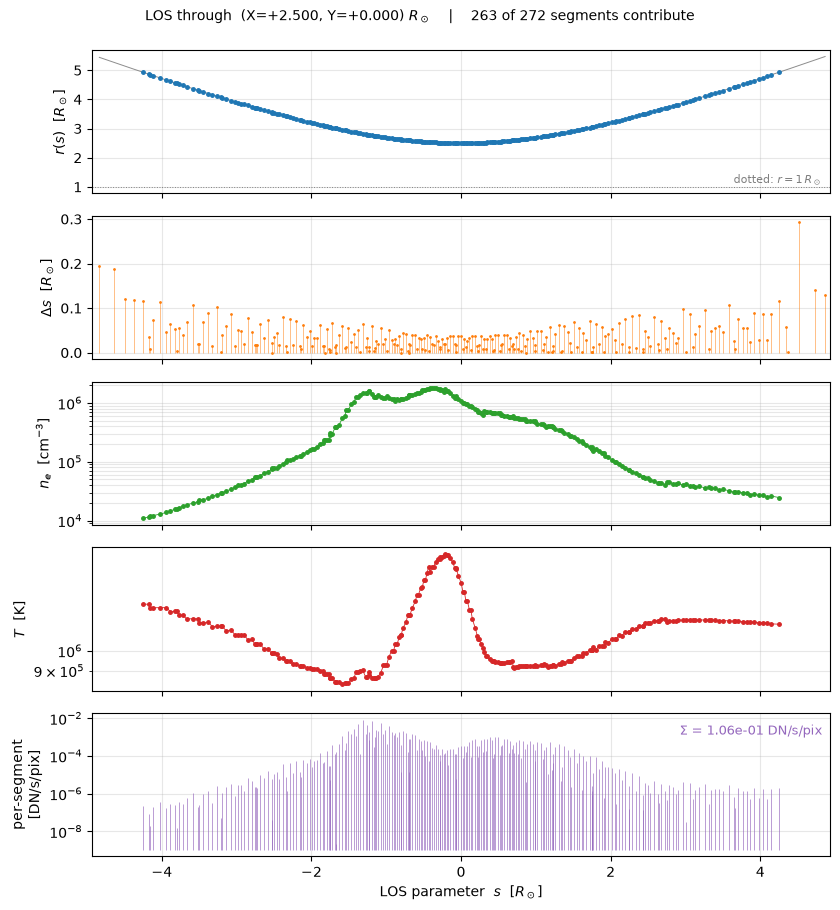

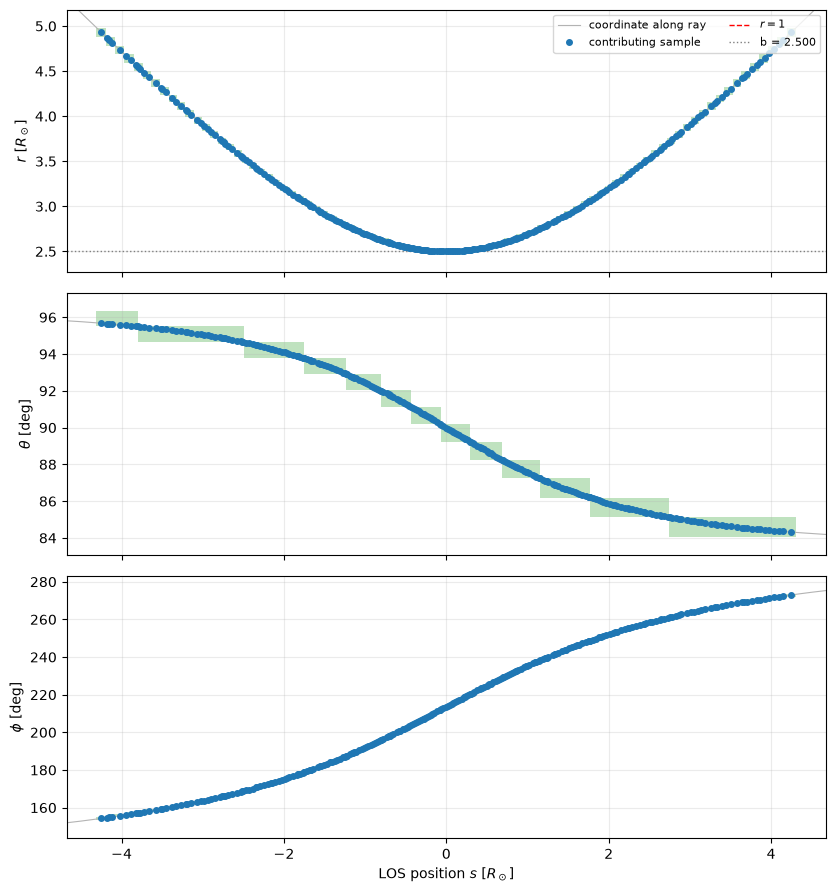

(+2.50,+0.00)  kept=263/272  Σ=1.059e-01 DN/s/pix  inside=100.0%  verdict=PASS


In [9]:
PROBES = [(1.2, 0.3), (0.5, 0.0), (2.5, 0.0)]   # (X, Y) impact points on the sky [R_sun]

for X, Y in PROBES:
    s = analyze_los(X, Y, x_img, y_img, e_los,
                    cube.r, cube.theta, cube.phi, cube.ne, cube.T,
                    T_resp=T_resp, R_resp=R_resp)
    vp = s['voxel_proof']
    print(f"({X:+.2f},{Y:+.2f})  kept={int(s['kept'].sum())}/{s['kept'].size}  "
          f"Σ={s.get('I_total_clipped', s['I_total']):.3e} DN/s/pix  "
          f"inside={vp['frac_inside_pct']:.1f}%  verdict={'PASS' if vp['pass'] else 'CHECK'}")


In [13]:
cube = load_mhd(str(REPO / 'data' / 'mhd_data_0220.h5'), t_iso=1.0e6)
print(cube.summary())        # expect: case=density_only  fmt=arms, T flat at 1e6 K

T_resp, R_resp = load_response(str(REPO / 'data' / 'aia_temp_response_chiantifix.npz'), 171)
n_obs, e_los, x_img, y_img = make_observer(-70, 0)     # no obs_time → explicit angles


MHDCube  case=density_only  fmt=arms
  r     : 1.004 – 4.996 R_sun  (n=500)
  theta : 11.2 – 168.8 deg  (n=500)
  phi   : -16.5 – 73.5 deg  (n=250)
  ne    : 0.00e+00 – 5.81e+09 cm^-3   shape=(500, 500, 250)
  T     : 1.00e+06 – 1.00e+06 K   [isothermal (1.000e+06 K)]


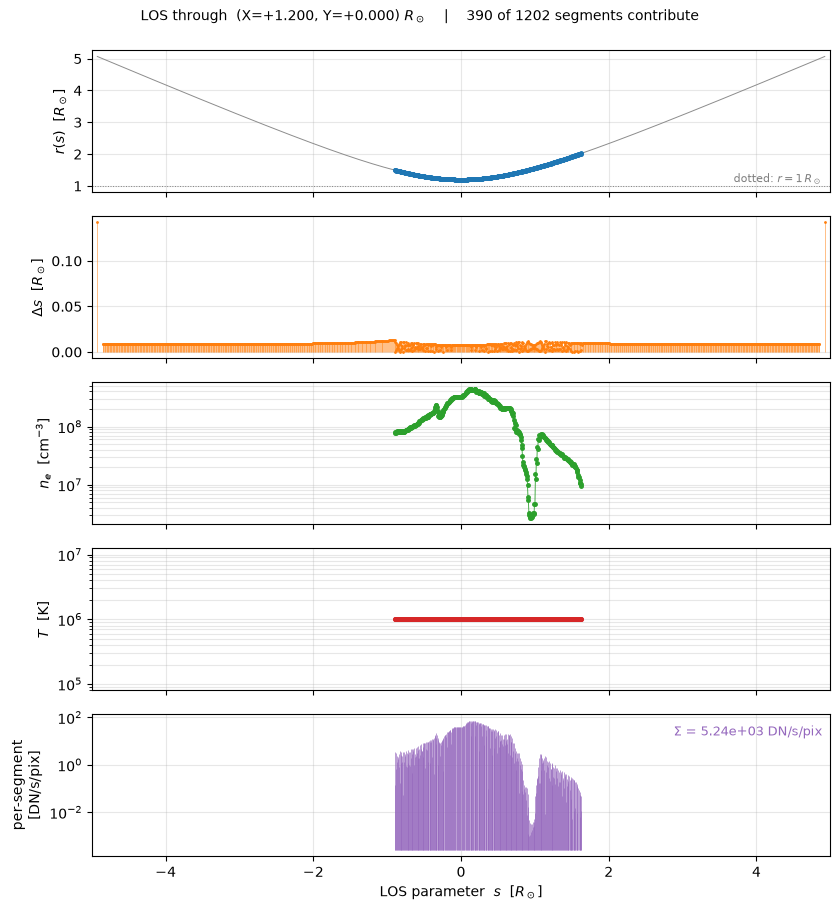

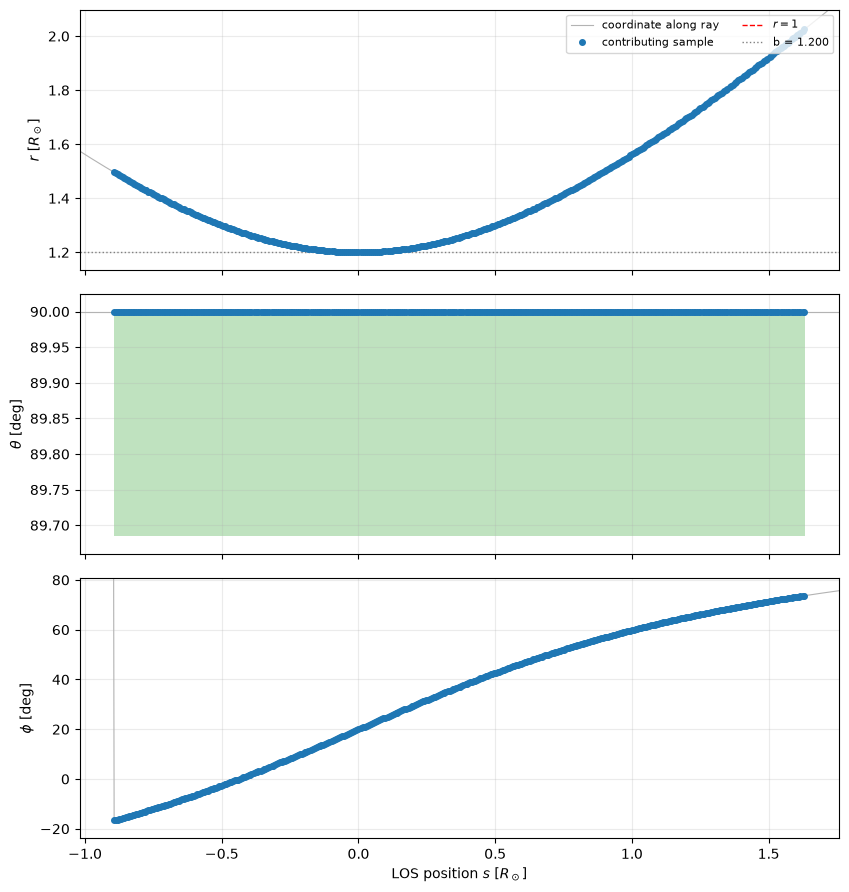

(+1.20,+0.00)  kept=390/1202  Σ=5.239e+03 DN/s/pix  inside=100.0%  verdict=PASS


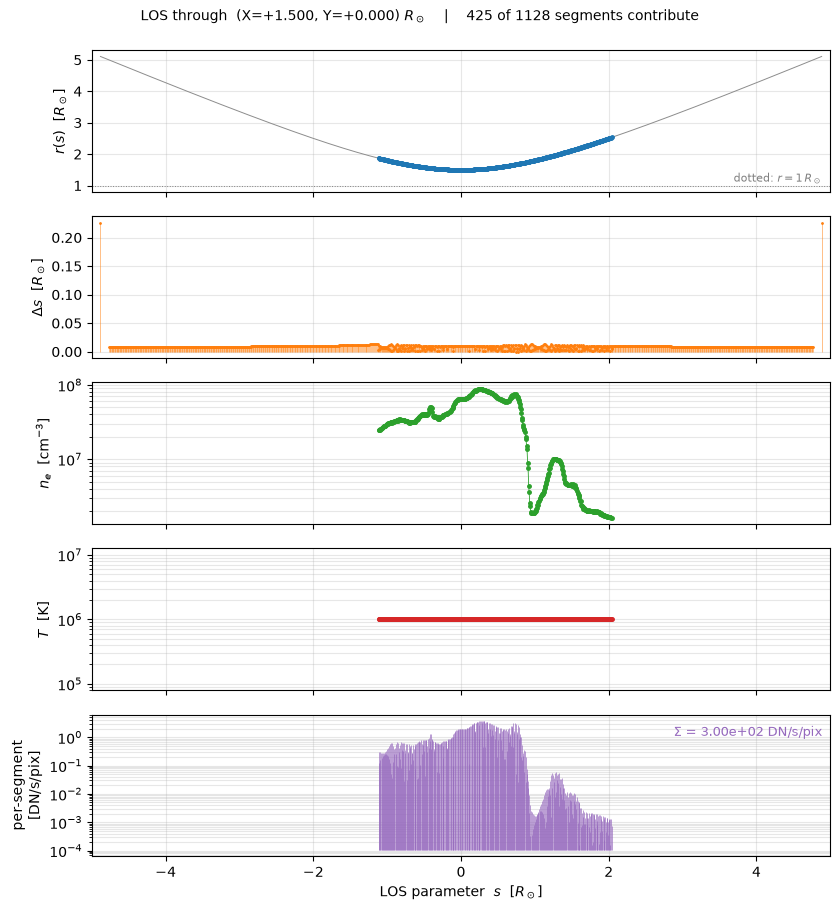

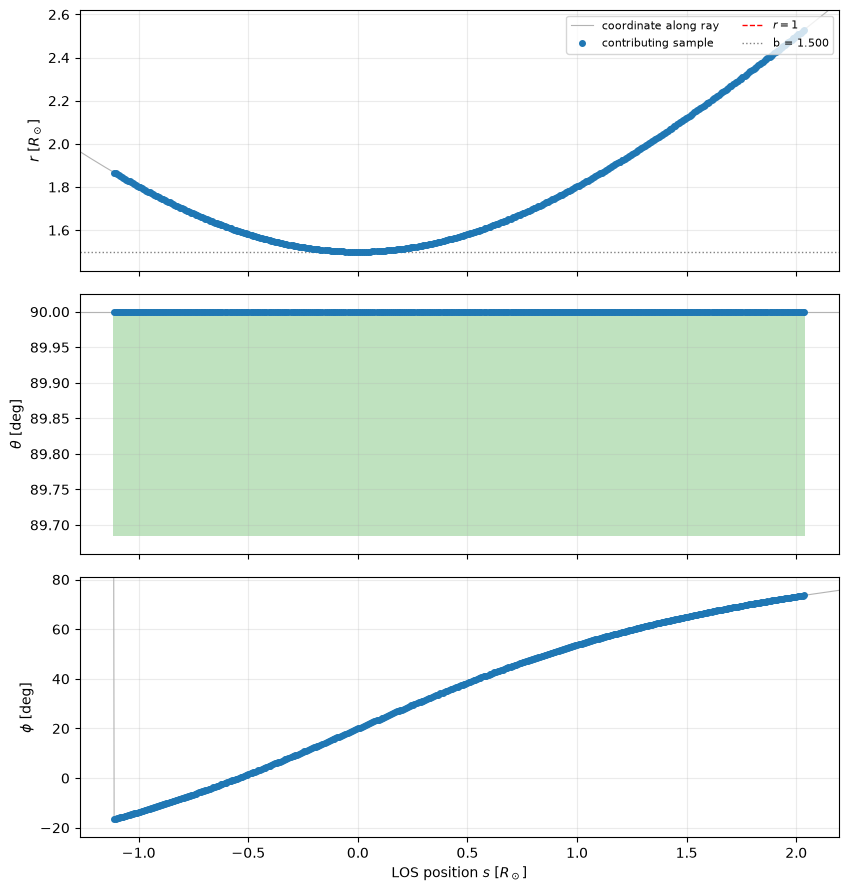

(+1.50,+0.00)  kept=425/1128  Σ=2.999e+02 DN/s/pix  inside=100.0%  verdict=PASS


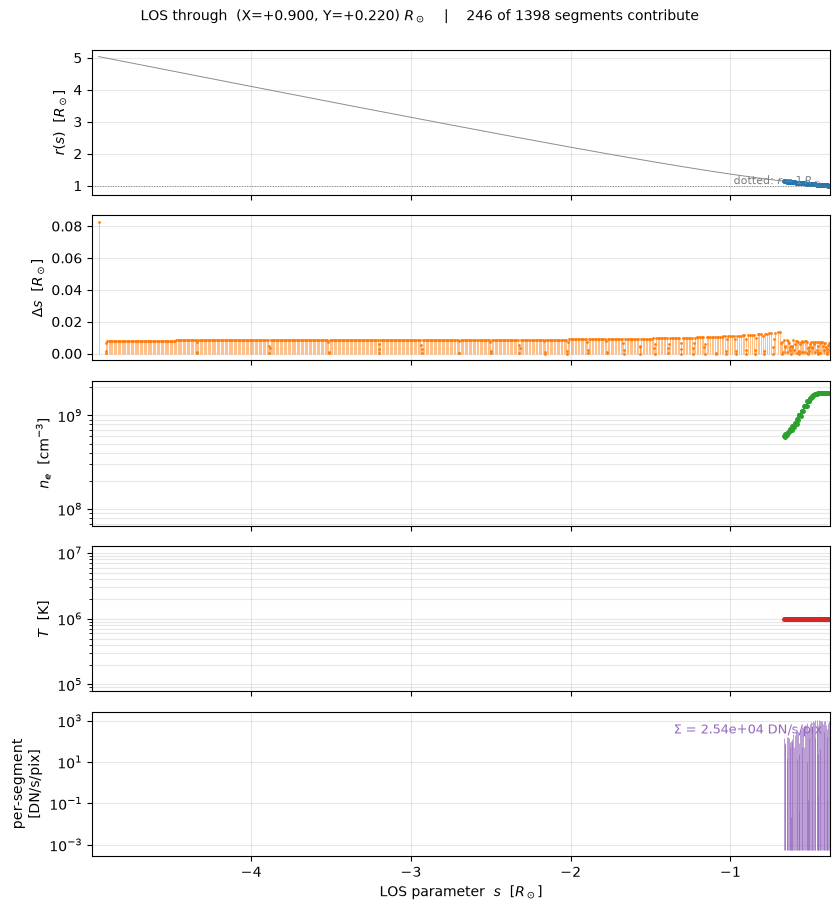

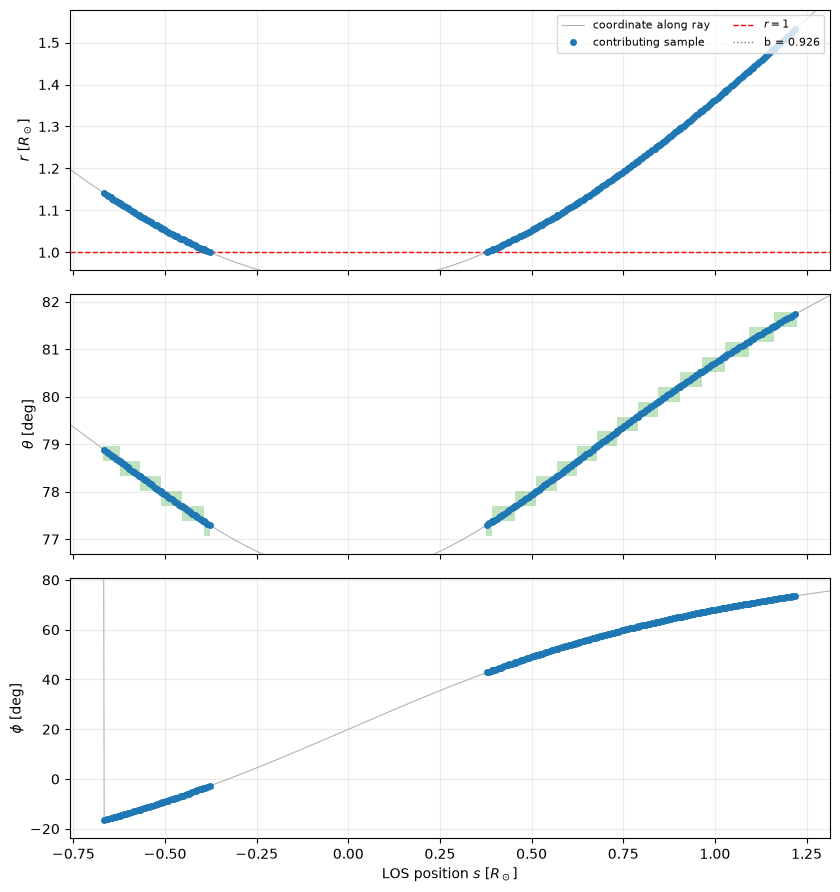

(+0.90,+0.22)  kept=246/1398  Σ=2.540e+04 DN/s/pix  inside=100.0%  verdict=PASS


In [15]:
PROBES = [(1.2, 0.0), (1.5, 0.0), (0.9, 0.22)]

for X, Y in PROBES:
    s = analyze_los(X, Y, x_img, y_img, e_los,
                    cube.r, cube.theta, cube.phi, cube.ne, cube.T,
                    T_resp=T_resp, R_resp=R_resp)
    vp = s['voxel_proof']
    print(f"({X:+.2f},{Y:+.2f})  kept={int(s['kept'].sum())}/{s['kept'].size}  "
          f"Σ={s.get('I_total_clipped', s['I_total']):.3e} DN/s/pix  "
          f"inside={vp['frac_inside_pct']:.1f}%  verdict={'PASS' if vp['pass'] else 'CHECK'}")
